In [1]:
import sys
sys.path.insert(0, '/disk/plasma/xw2/VDF_Fit_v1/src')

from preprocess_data_for_fit import readCDFs, check_data_consistency, get_EAS_energy, convert_eV_2Velocity, \
    getVelocityArray_EAS, transferToSRF, slice_xarrayEAS, get_SO_MAG_SRF_Normal, average_MAG_around_timeStamp, \
    getPitchAngle, average_PAS_around_timeStamp, allocateGridIdx
from utils import extract_time_from_filename
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LogNorm
import os
from datetime import datetime
from matplotlib.dates import DateFormatter
import pickle
import xarray as xr
from cdasws import CdasWs
from cdasws.datarepresentation import DataRepresentation as dr
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.stats import pearsonr
import astropy.units as u

In [2]:
# ===================== SWA data loaders =====================
def get_SO_MAG_RTN_Normal(timeRange):
    cdas = CdasWs()
    timeRange_str = [
        pd.to_datetime(timeRange[0]).strftime('%Y-%m-%dT%H:%M:%SZ'),
        pd.to_datetime(timeRange[-1]).strftime('%Y-%m-%dT%H:%M:%SZ')
    ]
    MAG_data = cdas.get_data('SOLO_L2_MAG-RTN-NORMAL', ['B_RTN'], timeRange_str[0], timeRange_str[1],
                             dataRepresentation=dr.XARRAY)[1]
    return MAG_data


def get_SO_PAS_Grnd_Moment_RTN(timeRange):
    cdas = CdasWs()
    timeRange_str = [
        pd.to_datetime(timeRange[0]).strftime('%Y-%m-%dT%H:%M:%SZ'),
        pd.to_datetime(timeRange[-1]).strftime('%Y-%m-%dT%H:%M:%SZ')
    ]
    PAS_data = cdas.get_data('SOLO_L2_SWA-PAS-GRND-MOM', ['V_RTN', 'N'], timeRange_str[0], timeRange_str[1],
                             dataRepresentation=dr.XARRAY)[1]
    return PAS_data


def get_SWA_data(eas1Files, eas2Files, timeRes='1min', custom_timeRange=None):
    psdEAS1, datasetEAS1 = readCDFs(eas1Files)  # 10s resolution
    # psdEAS2, datasetEAS2 = readCDFs(eas2Files)  # PAD-only
    check_data_consistency(psdEAS1, datasetEAS1)
    # check_data_consistency(psdEAS2, datasetEAS2)  # PAD-only

    # Eas1 (only EPOCH is needed for time_stamps; rest is PAD-only)
    psdEAS1 = psdEAS1.where(psdEAS1 != psdEAS1.attrs['FILLVAL'], np.nan)
    # energyEAS1 = get_EAS_energy(datasetEAS1[0], instrument='EAS1')   # PAD-only
    # psd_unit = psdEAS1.attrs['UNITS']                                # PAD-only
    # thetaEAS1 = np.deg2rad(psdEAS1['SWA_EAS_ELEVATION'].values)      # PAD-only
    # phiEAS1   = np.deg2rad(psdEAS1['SWA_EAS_AZIMUTH'].values)        # PAD-only
    # vEAS1     = convert_eV_2Velocity(energyEAS1.values)              # PAD-only
    psdEAS1['EPOCH'] = psdEAS1['EPOCH'].astype('datetime64[s]')

    # Eas2 (PAD-only, commented out)
    # psdEAS2 = psdEAS2.where(psdEAS2 != psdEAS2.attrs['FILLVAL'], np.nan)
    # energyEAS2 = get_EAS_energy(datasetEAS2[0], instrument='EAS2')
    # thetaEAS2 = np.deg2rad(psdEAS2['SWA_EAS_ELEVATION'].values)
    # phiEAS2   = np.deg2rad(psdEAS2['SWA_EAS_AZIMUTH'].values)
    # vEAS2     = convert_eV_2Velocity(energyEAS2.values)
    # psdEAS2['EPOCH'] = psdEAS2['EPOCH'].astype('datetime64[s]')

    # Transfer To Spacecraft Frame (PAD-only)
    # eas1_toSRF = datasetEAS1[0]['EAS1_TO_SRF'].values.copy()
    # eas2_toSRF = datasetEAS2[0]['EAS2_TO_SRF'].values.copy()
    # vxEAS1, vyEAS1, vzEAS1 = getVelocityArray_EAS(thetaEAS1, phiEAS1, vEAS1)
    # vxEAS2, vyEAS2, vzEAS2 = getVelocityArray_EAS(thetaEAS2, phiEAS2, vEAS2)
    # normalVec_xz = [0, 1, 0]
    # vEAS1_srf = transferToSRF(eas1_toSRF, vxEAS1, vyEAS1, vzEAS1)
    # vEAS2_srf = transferToSRF(eas2_toSRF, vxEAS2, vyEAS2, vzEAS2)

    if custom_timeRange is None:
        timeRange_EAS = [psdEAS1['EPOCH'].values[0], psdEAS1['EPOCH'].values[-1]]
        print(f"Using default time range: {timeRange_EAS[0]} to {timeRange_EAS[1]}")
    else:
        timeRange_EAS = custom_timeRange
        print(f"Using provided custom time range: {timeRange_EAS[0]} to {timeRange_EAS[1]}")

    psd1 = slice_xarrayEAS(psdEAS1, timeRange_EAS, timeFreq=timeRes)
    # psd2 = slice_xarrayEAS(psdEAS2, timeRange_EAS, timeFreq=timeRes)  # PAD-only
    time_stamps = psd1['EPOCH'].values.astype('datetime64[s]')

    # MAG SRF + pitch-angle (PAD-only)
    # magData = get_SO_MAG_SRF_Normal(timeRange_EAS)
    # B_srf = magData['B_SRF'].copy()
    # magVector_srf = average_MAG_around_timeStamp(B_srf, time_stamps)
    # PA_eas1 = getPitchAngle(vEAS1_srf, magVector_srf, time_stamps)
    # PA_eas2 = getPitchAngle(vEAS2_srf, magVector_srf, time_stamps)

    magData_rtn = get_SO_MAG_RTN_Normal(timeRange_EAS)
    B_rtn = magData_rtn['B_RTN'].copy()
    magVector_rtn = average_MAG_around_timeStamp(B_rtn, time_stamps)

    # PAS velocity data
    pasData = get_SO_PAS_Grnd_Moment_RTN(timeRange_EAS)
    vpVector = average_PAS_around_timeStamp(pasData['V_RTN'], time_stamps)
    # protonDensity = average_PAS_around_timeStamp(pasData['N'], time_stamps)  # not needed

    # ----- PAD computation (commented out, not needed) -----
    # desiredEnergyIdx = np.where((energyEAS1 > 50) & (energyEAS1 < 2000))[0]
    # pitchAngleBin_and_idxArray = None
    #
    # def get_PAD(psd1, psd2, desiredEnergyIdx, time_stamps, pitchAngleVariables=None):
    #     if pitchAngleVariables is not None:
    #         pitchAngleBound = pitchAngleVariables['pitchAngleBound']
    #         PA_bin_indices_eas1 = pitchAngleVariables['PA_bin_indices_eas1']
    #         PA_bin_indices_eas2 = pitchAngleVariables['PA_bin_indices_eas2']
    #     else:
    #         pitchAngleBound = np.arange(0, 185, 5)
    #         PA_bin_indices_eas1 = allocateGridIdx(PA_eas1, pitchAngleBound, rightClosed=True)
    #         PA_bin_indices_eas2 = allocateGridIdx(PA_eas2, pitchAngleBound, rightClosed=True)
    #
    #     midpoints_PA_bins = (pitchAngleBound[:-1] + pitchAngleBound[1:]) / 2
    #     psd_averaged = pd.DataFrame(np.zeros((len(psd1['EPOCH']), len(pitchAngleBound) - 1)),
    #                                 index=psd1['EPOCH'], columns=midpoints_PA_bins)
    #
    #     for timeId in range(len(time_stamps)):
    #         PA_bin_locations_eas1 = {i: np.where(PA_bin_indices_eas1[timeId] == i) for i in range(0, len(pitchAngleBound) - 1)}
    #         PA_bin_locations_eas2 = {i: np.where(PA_bin_indices_eas2[timeId] == i) for i in range(0, len(pitchAngleBound) - 1)}
    #         for (eas1PA_bin_number, eas1PA_indices_Tuple), (eas2PA_bin_number, eas2PA_indices_Tuple) in zip(
    #                 PA_bin_locations_eas1.items(), PA_bin_locations_eas2.items()):
    #             desiredEnergy_loc_eas1 = np.sort(np.concatenate(
    #                 [np.where(eas1PA_indices_Tuple[1] == Idx)[0] for Idx in desiredEnergyIdx]))
    #             desiredEnergy_loc_eas2 = np.sort(np.concatenate(
    #                 [np.where(eas2PA_indices_Tuple[1] == Idx)[0] for Idx in desiredEnergyIdx]))
    #             psd_selection_eas1 = psd1.isel(EPOCH=timeId).values[
    #                 eas1PA_indices_Tuple[0][desiredEnergy_loc_eas1],
    #                 eas1PA_indices_Tuple[1][desiredEnergy_loc_eas1],
    #                 eas1PA_indices_Tuple[2][desiredEnergy_loc_eas1]]
    #             psd_selection_eas2 = psd2.isel(EPOCH=timeId).values[
    #                 eas2PA_indices_Tuple[0][desiredEnergy_loc_eas2],
    #                 eas2PA_indices_Tuple[1][desiredEnergy_loc_eas2],
    #                 eas2PA_indices_Tuple[2][desiredEnergy_loc_eas2]]
    #             psd_selection = np.concatenate([psd_selection_eas1, psd_selection_eas2])
    #             psd_averaged.loc[psd1['EPOCH'].values[timeId], midpoints_PA_bins[eas1PA_bin_number]] = \
    #                 np.mean(psd_selection) if len(psd_selection) > 0 else 0
    #     return psd_averaged
    #
    # psd_averaged = get_PAD(psd1, psd2, desiredEnergyIdx, time_stamps,
    #                        pitchAngleVariables=pitchAngleBin_and_idxArray)

    return magVector_rtn, vpVector, time_stamps


# ===================== PAD plot =====================
def plot_PAD(psd_averaged, output_dir, vmin=0.0, vmax=None, axes=None, fig_ref=None,
             Y_labelSize=14, TICK_label=11):
    if axes is None:
        fig, ax = plt.subplots(1, figsize=(11, 3.5), sharex=True)
        fig.subplots_adjust(left=0.1, right=0.99, top=0.95, bottom=0.2)
    else:
        ax = axes
        fig = fig_ref

    if vmin is None:
        vmin = np.nanmin(psd_averaged.values)
    if vmax is None:
        vmax = np.nanmax(psd_averaged.values)

    X, Y = np.meshgrid(psd_averaged.index.values, psd_averaged.columns.values)
    pcm = ax.pcolormesh(X.T, Y.T, psd_averaged.values, cmap='jet', shading='nearest', vmin=vmin, vmax=vmax)

    ax.set_ylabel(r'$Pitch\ Angle\ [\degree]$', fontsize=Y_labelSize)

    if axes is not None:
        pos = ax.get_position()
        cbar_ax = fig.add_axes([1.0, pos.y0, 0.02, pos.height])
        bar = fig.colorbar(pcm, cax=cbar_ax)
        bar.set_label('$Phase\\ Space\\ Density$\n$[s^3km^{-6}]$', fontsize=14)
        bar.formatter.set_powerlimits((0, 0))
    else:
        bar = fig.colorbar(pcm, pad=0.02)
        bar.set_label('$Phase\\ Space\\ Density$\n$[s^3km^{-6}]$', fontsize=Y_labelSize)
        bar.formatter.set_powerlimits((0, 0))

    if axes is None:
        tmax = psd_averaged.index[-1]
        tmin = psd_averaged.index[0]
        time_span = (tmax - tmin).total_seconds() / (24 * 3600)
        if time_span <= 1:
            major_interval = 3
            minor_interval = 1
            date_format = '%H:%M\n%Y-%m-%d'
        elif time_span <= 3:
            major_interval = 6
            minor_interval = 2
            date_format = '%H:%M\n%Y-%m-%d'
        elif time_span <= 7:
            major_interval = 12
            minor_interval = 4
            date_format = '%H:%M\n%d %b'
        else:
            major_interval = 24
            minor_interval = 6
            date_format = '%d %b %Y'

        ax.xaxis.set_major_locator(mdates.HourLocator(interval=major_interval))
        ax.xaxis.set_major_formatter(mdates.DateFormatter(date_format))
        ax.xaxis.set_minor_locator(mdates.HourLocator(interval=minor_interval))
        ax.tick_params(axis='x', labelsize=TICK_label)

        if output_dir is not None:
            figname = os.path.join(output_dir, 'PAD_' + psd_averaged.index[0].strftime('%Y%m%d%H%M%S') +
                                   '_' + psd_averaged.index[-1].strftime('%Y%m%d%H%M%S') + '.png')
            fig.savefig(figname, dpi=200)
            plt.close()
            print(f'\nPAD plot saved to {figname}')
        else:
            print('output_dir not specified.')


# ===================== unit helpers =====================
def vel_to_eV(input):
    # input in cm/s, returns eV (perp)
    m_e = 9.109 * 10. ** (-28.)
    eV_to_Erg = 1.602 * (10. ** (-12.))
    return (m_e / 2) * (input ** 2) * (1 / eV_to_Erg)


def vel_to_eV_para(input):
    m_e = 9.109 * 10. ** (-28.)
    eV_to_Erg = 1.602 * (10. ** (-12.))
    return (m_e) * (input ** 2) * (1 / eV_to_Erg)


# ===================== gap-fill for time series =====================
def fill_time_gaps(data, time_index=None, freq='1min', gap_threshold='1min'):
    if time_index is None:
        time_index = data.index

    if time_index.duplicated().any():
        print(f"Warning: Found {time_index.duplicated().sum()} duplicate time indices")
        data = data[~data.index.duplicated(keep='first')]
        time_index = data.index

    if len(data) == 0:
        return data

    time_diff = time_index.to_series().diff()
    gap_threshold_td = pd.Timedelta(gap_threshold)
    freq_td = pd.Timedelta(freq)
    gap_mask = time_diff > gap_threshold_td

    if not gap_mask.any():
        print("No time gaps found larger than threshold")
        return data

    print(f"Found {gap_mask.sum()} time gaps larger than {gap_threshold}")

    new_times = []
    if isinstance(data, pd.DataFrame):
        new_values = {col: [] for col in data.columns}
    else:
        new_values = []

    for i in range(len(data)):
        current_time = data.index[i]
        new_times.append(current_time)
        if isinstance(data, pd.Series):
            new_values.append(data.iloc[i])
        else:
            for col in data.columns:
                new_values[col].append(data.iloc[i][col])

        if i < len(data) - 1:
            next_time = data.index[i + 1]
            time_gap = next_time - current_time

            if time_gap > gap_threshold_td:
                gap_start = current_time + freq_td
                gap_end = next_time - freq_td

                if gap_start <= gap_end:
                    gap_times = pd.date_range(start=gap_start, end=gap_end, freq=freq)

                    for gap_time in gap_times:
                        new_times.append(gap_time)
                        if isinstance(data, pd.Series):
                            new_values.append(np.nan)
                        else:
                            for col in data.columns:
                                new_values[col].append(np.nan)

    new_time_index = pd.DatetimeIndex(new_times)

    if isinstance(data, pd.Series):
        filled_data = pd.Series(new_values, index=new_time_index, name=data.name)
    else:
        filled_data = pd.DataFrame(new_values, index=new_time_index)

    print(f"Added {len(filled_data) - len(data)} NaN points")
    return filled_data


# ===================== Fitting-result readers =====================
def read_fit_results(pickle_dir, folder_names, fit_result_files, segment_IDs=None, exclude_IDs=None):
    result_df = pd.DataFrame()
    time_range_dict = {}

    for f_id, folder_name in enumerate(folder_names):
        file_path = os.path.join(pickle_dir, folder_name, fit_result_files[f_id])
        with open(file_path, 'rb') as file:
            print('loading file: ', file_path)
            data_dict = pickle.load(file)

        epoch_EAS = data_dict['time_stamps']
        time_range_dict[folder_name] = [epoch_EAS[0], epoch_EAS[-1]]

        if segment_IDs is not None:
            filtered_indices = [idx for idx, epoch_id in enumerate(data_dict['epoch_id']) if epoch_id in segment_IDs[f_id]]
        elif exclude_IDs is not None and folder_name in exclude_IDs:
            filtered_indices = [idx for idx, epoch_id in enumerate(data_dict['epoch_id']) if epoch_id not in exclude_IDs[folder_name]]
        else:
            filtered_indices = range(len(data_dict['epoch_id']))

        temp_df = pd.DataFrame({
            'epoch_id': [data_dict['epoch_id'][i] for i in filtered_indices],
            'red_chi_b': [data_dict['redChiSqr_beam'][i] for i in filtered_indices],
            'red_chi_overall': [data_dict['redChiSqr'][i] for i in filtered_indices],
            'Ts_anti_moment': [data_dict['T_antiPara_b'][i] for i in filtered_indices],
            'vdf_fittedParams': [data_dict['r_vdf'][i] for i in filtered_indices]
        }, index=[epoch_EAS[i] for i in filtered_indices])

        result_df = pd.concat([result_df, temp_df])

    result_df.sort_index(inplace=True)
    return result_df, time_range_dict


def filter_data_by_criteria(result_df, t_start, t_end, criteria_mask):
    if isinstance(t_end, str):
        t_end_adjusted = pd.Timestamp(t_end) + pd.Timedelta(seconds=1)
    else:
        t_end_adjusted = t_end + pd.Timedelta(seconds=1)

    df_filtered = result_df[criteria_mask]
    df_tSliced = df_filtered.loc[t_start:t_end]
    return df_tSliced


def extract_temperature_data(df_tSliced, component_type='core'):
    temp_list = []
    temp2_list = []
    density_list = []

    if component_type == 'core':
        for v in df_tSliced['vdf_fittedParams']:
            if 'n_c' in v.params:
                density_list.append(v.params['n_c'].value)
            else:
                density_list.append(np.nan)

            if 'v_th_perp_c' in v.params:
                temp_list.append(vel_to_eV(v.params['v_th_perp_c'].value))
            else:
                temp_list.append(np.nan)

            if 'v_th_par_c' in v.params:
                temp2_list.append(vel_to_eV(v.params['v_th_par_c'].value))
            else:
                temp2_list.append(np.nan)

    elif component_type == 'strahl':
        for v in df_tSliced['vdf_fittedParams']:
            if 'n_b' in v.params:
                density_list.append(v.params['n_b'].value)
            else:
                density_list.append(np.nan)

            if 'v_th_par_b' in v.params:
                temp_list.append(vel_to_eV(v.params['v_th_par_b'].value))
            elif 'v_th_par_b_anti_par' in v.params:
                temp_list.append(vel_to_eV(v.params['v_th_par_b_anti_par'].value))
            else:
                temp_list.append(np.nan)

    temperature = pd.DataFrame(temp_list, index=df_tSliced.index)
    density = pd.DataFrame(density_list, index=df_tSliced.index)
    if component_type == 'core':
        temperature2 = pd.DataFrame(temp2_list, index=df_tSliced.index)
        return temperature, density, temperature2
    else:
        return temperature, density


def process_electron_components(result_df, t_start, t_end):
    mask_redchi_strahl = (result_df['red_chi_b'] >= 0.7) & (result_df['red_chi_b'] <= 1.2) & \
                         (result_df['red_chi_overall'] >= 0.6) & (result_df['red_chi_overall'] <= 1.4)

    mask_redchi_core = (result_df['red_chi_overall'] >= 0.6) & (result_df['red_chi_overall'] <= 1.4) & \
                       ((result_df['red_chi_b'].between(0.65, 1.2)) | (result_df['red_chi_b'].isna()))

    df_tSliced_strahl = filter_data_by_criteria(result_df, t_start, t_end, mask_redchi_strahl)
    df_tSliced_core = filter_data_by_criteria(result_df, t_start, t_end, mask_redchi_core)

    Ts_anti_fit, n_s = extract_temperature_data(df_tSliced_strahl, 'strahl')
    Tcore, n_c, Tcore_para = extract_temperature_data(df_tSliced_core, 'core')

    Ts_anti_moment = df_tSliced_strahl['Ts_anti_moment']

    return {
        'T_strahl_fit': Ts_anti_fit,
        'T_strahl_moment': Ts_anti_moment,
        'n_strahl': n_s,
        'T_core': Tcore,
        'T_core_para': Tcore_para,
        'n_core': n_c,
        'df_strahl': df_tSliced_strahl,
        'df_core': df_tSliced_core
    }


# ===================== HIS data =====================
def get_datestr_forHis(folder_names):
    date_list = [item[:8] for f in folder_names for item in f.split('_')]
    return sorted(list(set(date_list)))


def readCDF(filePath_list):
    cdas = CdasWs()
    if len(filePath_list) == 1:
        temp_eas = cdas.read_data(filePath_list[0], data_representation=dr.XARRAY)
        temp_eas = temp_eas.drop_vars('EPOCH_STOP') if 'EPOCH_STOP' in temp_eas.variables else temp_eas
    else:
        raw_dataArrays = [cdas.read_data(filePath, data_representation=dr.XARRAY) for filePath in filePath_list]
        temp_eas = [ds.drop_vars('EPOCH_STOP') if 'EPOCH_STOP' in ds.variables else ds for ds in raw_dataArrays]
        temp_eas = xr.concat(temp_eas, dim='EPOCH')
        temp_eas = temp_eas.sel(EPOCH=~temp_eas.get_index('EPOCH').duplicated())
        temp_eas = temp_eas.sortby('EPOCH')

    return temp_eas


# ===================== correlation with HIS =====================
def calculate_correlations(df_downsampled, o7o6, c6c5, feo):
    mask_o7o6 = ~np.isnan(df_downsampled.values.flatten()) & ~np.isnan(o7o6.values)
    mask_c6c5 = ~np.isnan(df_downsampled.values.flatten()) & ~np.isnan(c6c5.values)
    mask_feo = ~np.isnan(df_downsampled.values.flatten()) & ~np.isnan(feo.values)

    filtered_T_average_o7o6 = np.array(df_downsampled.values.flatten())[mask_o7o6]
    filtered_o7o6 = o7o6[mask_o7o6]
    filtered_T_average_c6c5 = np.array(df_downsampled.values.flatten())[mask_c6c5]
    filtered_c6c5 = c6c5[mask_c6c5]
    filtered_T_average_feo = np.array(df_downsampled.values.flatten())[mask_feo]
    filtered_feo = feo[mask_feo]

    pearson_o7o6, p_o7o6 = pearsonr(filtered_T_average_o7o6, np.log10(filtered_o7o6))
    pearson_c6c5, p_c6c5 = pearsonr(filtered_T_average_c6c5, np.log10(filtered_c6c5))
    pearson_feo, p_feo = pearsonr(filtered_T_average_feo, np.log10(filtered_feo))

    corr = {'o7o6': (pearson_o7o6, p_o7o6), 'c6c5': (pearson_c6c5, p_c6c5), 'feo': (pearson_feo, p_feo)}
    return corr


def pchip_downsample(df_temperature, hisDataTime, SG_filter=False, savgol_window=11, savgol_order=2):
    df_clean = df_temperature.reset_index().drop_duplicates('index').set_index('index').sort_index()
    temp_values = df_clean.values.flatten()
    time_index = df_clean.index
    if SG_filter:
        if savgol_window % 2 == 0:
            savgol_window += 1
        filtered_temp = savgol_filter(temp_values, savgol_window, savgol_order)
    else:
        filtered_temp = temp_values

    time_numeric = mdates.date2num(time_index)
    his_time_numeric = mdates.date2num(hisDataTime)
    in_range_mask = (his_time_numeric >= np.min(time_numeric)) & (his_time_numeric <= np.max(time_numeric))
    T_average = np.full(len(hisDataTime), np.nan)

    if np.any(in_range_mask):
        interp_func = PchipInterpolator(time_numeric, filtered_temp)
        T_average[in_range_mask] = interp_func(his_time_numeric[in_range_mask])

    return pd.DataFrame(T_average, index=hisDataTime, columns=['value'])


def correlation_with_HIS(eVDF_param, HISTimeSeries, HIS_data_slice, SG_filter=False):
    eVDF_param_downsampled = pchip_downsample(eVDF_param, HISTimeSeries, SG_filter=SG_filter)

    o7o6 = HIS_data_slice['O7_O6_RATIO']
    c6c5 = HIS_data_slice['C6_C5_RATIO']
    feo = HIS_data_slice['FE_O_ABUN']

    correlations = calculate_correlations(eVDF_param_downsampled, o7o6, c6c5, feo)
    return correlations, eVDF_param_downsampled

In [3]:
dataDir = '../data/SolO/vdfs/'
eas1FileName = [
    'solo_L2_swa-eas1-nm3d-psd_20220302T060509-20220302T120459_corrLPP_V01.cdf',
    'solo_L2_swa-eas1-nm3d-psd_20220302T120509-20220302T180459_corrLPP_V01.cdf',
    'solo_L2_swa-eas1-nm3d-psd_20220302T180509-20220302T235949_corrLPP_V01.cdf',
    'solo_L2_swa-eas1-nm3d-psd_20220302T235959-20220303T065059_corrLPP_V01.cdf',
    'solo_L2_swa-eas1-nm3d-psd_20220303T065109-20220303T125059_corrLPP_V01.cdf',
    'solo_L2_swa-eas1-nm3d-psd_20220303T125109-20220303T185059_corrLPP_V01.cdf',
    'solo_L2_swa-eas1-nm3d-psd_20220303T185109-20220303T235949_corrLPP_V01.cdf',
    'solo_L2_swa-eas1-nm3d-psd_20220303T235959-20220304T060459_corrLPP_V01.cdf',
    'solo_L2_swa-eas1-nm3d-psd_20220304T060509-20220304T120459_corrLPP_V01.cdf',
    'solo_L2_swa-eas1-nm3d-psd_20220304T120509-20220304T180459_corrLPP_V01.cdf',
    'solo_L2_swa-eas1-nm3d-psd_20220304T180509-20220304T235949_corrLPP_V01.cdf',    
    'solo_L2_swa-eas1-nm3d-psd_20220304T235959-20220305T060459_corrLPP_V01.cdf',
    'solo_L2_swa-eas1-nm3d-psd_20220305T060509-20220305T181149_corrLPP_V01.cdf',
    'solo_L2_swa-eas1-nm3d-psd_20220305T181159-20220305T235949_corrLPP_V01.cdf',
    'solo_L2_swa-eas1-nm3d-psd_20220305T235959-20220306T060459_corrLPP_V01.cdf',
    'solo_L2_swa-eas1-nm3d-psd_20220306T060509-20220306T120459_corrLPP_V01.cdf',
    'solo_L2_swa-eas1-nm3d-psd_20220306T120509-20220306T180459_corrLPP_V01.cdf',
    'solo_L2_swa-eas1-nm3d-psd_20220306T180509-20220306T235949_corrLPP_V01.cdf',
    ]
eas2FileName = [
    'solo_L2_swa-eas2-nm3d-psd_20220302T060509-20220302T120459_corrLPP_V01.cdf',
    'solo_L2_swa-eas2-nm3d-psd_20220302T120509-20220302T180459_corrLPP_V01.cdf',
    'solo_L2_swa-eas2-nm3d-psd_20220302T180509-20220302T235949_corrLPP_V01.cdf',
    'solo_L2_swa-eas2-nm3d-psd_20220302T235959-20220303T065059_corrLPP_V01.cdf',
    'solo_L2_swa-eas2-nm3d-psd_20220303T065109-20220303T125059_corrLPP_V01.cdf',
    'solo_L2_swa-eas2-nm3d-psd_20220303T125109-20220303T185059_corrLPP_V01.cdf',
    'solo_L2_swa-eas2-nm3d-psd_20220303T185109-20220303T235949_corrLPP_V01.cdf',
    'solo_L2_swa-eas2-nm3d-psd_20220303T235959-20220304T060459_corrLPP_V01.cdf',
    'solo_L2_swa-eas2-nm3d-psd_20220304T060509-20220304T120459_corrLPP_V01.cdf',
    'solo_L2_swa-eas2-nm3d-psd_20220304T120509-20220304T180459_corrLPP_V01.cdf',
    'solo_L2_swa-eas2-nm3d-psd_20220304T180509-20220304T235949_corrLPP_V01.cdf',
    'solo_L2_swa-eas2-nm3d-psd_20220304T235959-20220305T060459_corrLPP_V01.cdf',
    'solo_L2_swa-eas2-nm3d-psd_20220305T060509-20220305T181159_corrLPP_V01.cdf',
    'solo_L2_swa-eas2-nm3d-psd_20220305T181209-20220305T235949_corrLPP_V01.cdf',
    'solo_L2_swa-eas2-nm3d-psd_20220305T235959-20220306T060459_corrLPP_V01.cdf',
    'solo_L2_swa-eas2-nm3d-psd_20220306T060509-20220306T120459_corrLPP_V01.cdf',
    'solo_L2_swa-eas2-nm3d-psd_20220306T120509-20220306T180459_corrLPP_V01.cdf',
    'solo_L2_swa-eas2-nm3d-psd_20220306T180509-20220306T235949_corrLPP_V01.cdf',
    ]
eas1File = [dataDir + file for file in eas1FileName]
eas2File = [dataDir + file for file in eas2FileName]


In [4]:
magVector, vpVector, time_stamps = get_SWA_data(
    eas1Files=eas1File, eas2Files=eas2File, timeRes='1min', custom_timeRange=None
)
time_index = pd.DatetimeIndex(time_stamps)

/disk/anaconda/xw2/miniconda3/envs/SunSolarWind/lib/python3.10/site-packages/cdflib/xarray/cdf_to_xarray.py:619: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  created_vars[var_name] = xr.Variable(var_dims, var_data, attrs=var_atts)  # type: ignore[no-untyped-call]
/disk/anaconda/xw2/miniconda3/envs/SunSolarWind/lib/python3.10/site-packages/cdflib/xarray/cdf_to_xarray.py:619: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-

Is 'EPOCH' in chronological order? True
Do the 'EPOCH' coordinates match between psdEAS1 and original datasets? True
Data is identical for dataset index: 0
Data is identical for dataset index: 1
Data is identical for dataset index: 2
Data is identical for dataset index: 3
Data is identical for dataset index: 4
Data is identical for dataset index: 5
Data is identical for dataset index: 6
Data is identical for dataset index: 7
Data is identical for dataset index: 8
Data is identical for dataset index: 9
Data is identical for dataset index: 10
Data is identical for dataset index: 11
Data is identical for dataset index: 12
Data is identical for dataset index: 13
Data is identical for dataset index: 14
Data is identical for dataset index: 15
Data is identical for dataset index: 16
Data is identical for dataset index: 17


/tmp/ipykernel_608346/1979632493.py:37: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  psdEAS1['EPOCH'] = psdEAS1['EPOCH'].astype('datetime64[s]')


Using default time range: 2022-03-02T06:05:09.000000000 to 2022-03-06T23:59:49.000000000


/disk/anaconda/xw2/miniconda3/envs/SunSolarWind/lib/python3.10/site-packages/cdflib/xarray/cdf_to_xarray.py:291: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if new_data[new_data == var_atts["FILLVAL"]].size != 0:
/disk/anaconda/xw2/miniconda3/envs/SunSolarWind/lib/python3.10/site-packages/cdflib/xarray/cdf_to_xarray.py:619: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  created_vars[var_name] = xr.Variable(var_dims, var_data, attrs=var_atts)  # type: ignore[no-untyped-call]
/disk/anaconda/xw2/miniconda

In [5]:
# for draftRevision version of 2022.03.02
exclude_IDs = {
    '20220302060509_20220302120509':[1,3,8,9,17,20,23,24,27,28,34,37,39,40,45,48,49,51,56,58,59,60,63,65,66,71,75,78,79,82,86,94,96,
                                     107,109,110,117,120,129,137,139,145,147,154,156,160,161,162,167,168,169,171,172,173,174,178,180,183,190,198,
                                     200,203,209,215,217,232,233,238,240,246,254,255,258,276,284,294,297,
                                     303,307,321,322,328,335,338,340,341,343,346,347,348,351,356],
    '20220302120509_20220302180509':[19,21,27,28,39,40,47,51,53,54,56,61,70,75,78,94,95,96,
                                     103,107,108,109,112,114,116,120,125,136,137,142,156,157,158,177,180,182,187,190,192,194,195,198,
                                     201,202,206,209,210,212,214,220,228,229,238,240,243,245,247,251,256,260,261,265,266,267,268,269,275,278,283,284,286,287,288,291,293,294,295,298,
                                     301,304,305,306,310,313,314,320,322,324,325,330,334,337,340,341,342,344,345,347,348,351,353], # draftRevision version
    
    '20220302180509_20220303000509':[1,21,39,40,41,42,45,48,51,53,66,71,76,78,79,82,84,85,86,87,88,89,90,91,92,93,94,97,100,104,105,106,
                                     108,111,120,122,124,142,148,152,154,167,169,171,180,181,196,
                                     219,221,223,234,237,241,242,248,255,257,261,262,268,270,271,272,278,279,289,293,301,316,318,323,340,341], #draftRevision version
    '20220303000509_20220303060509':[112,125,95,97,98,103,104,105,106,108,115,116,118,121,124,127,128,129,132,136,139,140,141,143,146,149,156,160,161],
    '20220303060509_20220303120509':[296,298,300,304,305,307,309,310,312,321,331,333,335,336,337,339,340,341,342,343,344,346,347,349,352,354,355],
    '20220303120509_20220303180509':[198,31,35,39,41,57,61,62,64,69,70,85,89,93,108,116,118,124,139,144,152,156,157,159,161,162,163,164,167,168,169,175,176,178,179,180,181,182,183,185,186,187,188,189,192,193,195,196,199,200,202,203,210,218,220,223,225,232,235,240,241,242,249,250,252,254,265,266,273,277,278,280,282,285,286,287,292,293,294,300,301,302,307,311,312],
    '20220303180509_20220304000509':[107,108],
    '20220306120509_20220306180509':[56,86,91],
    '20220306175959_20220306235949':[3,21,22,23,26,28,30,36,37,38,41,43,45,50,51,52,54,55,56,57,59,60,67,71,74,78,84,85,87,88,89,91,92,95,96,98,
                                     100,101,103,106,108,113,116,130,132,133,137,139,140,142,144,148,151,152,158,160,164,165,167,168,170,171,172,177,180,187,188,189,194,195,196,197,199,124,127,
                                     200,205,206,207,208,209,211,212,215,221,223,226,228,229,234,235,236,240,254,256,257,259,268,270,272,274,277,281,283,287,289,292,296,
                                     301,302,305,311,317,323,332,333,337,341,344,345,346,347,348,
                                     174,175,214,224,244,245,247,262,266,269,280,284,285,291,294,300,318,331,336,350,136,143] # draftRevision Version
}
fit_data_names = [
    'VDF_eas_forFitting_20220302060509_20220302120509_1min.pkl',
    'VDF_eas_forFitting_20220302120509_20220302180509_1min.pkl', #results/draftRevision/
    'VDF_eas_forFitting_20220302180509_20220303000509_1min.pkl', # this's pkl in results/draftRevision/20220302180509_20220303000509/
    'VDF_eas_forFitting_20220303000509_20220303060509_1min.pkl',
    'VDF_eas_forFitting_20220303060509_20220303120509_1min.pkl',
    'VDF_eas_forFitting_20220303120509_20220303180509_1min.pkl',
    'VDF_eas_forFitting_20220303180509_20220304000509_1min.pkl',
    'VDF_eas_forFitting_20220304000509_20220304060509_1min.pkl',
    'VDF_eas_forFitting_20220304060509_20220304120509_1min.pkl',
    'VDF_eas_forFitting_20220304120509_20220304180509_1min.pkl',
    'VDF_eas_forFitting_20220304180509_20220305000509_1min.pkl',
    'VDF_eas_forFitting_20220305000509_20220305060509_1min.pkl',
    'VDF_eas_forFitting_20220305060509_20220305120509_1min.pkl',
    'VDF_eas_forFitting_20220305180509_20220306000509_1min.pkl',
    'VDF_eas_forFitting_20220306000509_20220306060509_1min.pkl',
    'VDF_eas_forFitting_20220306060509_20220306120509_1min.pkl',
    'VDF_eas_forFitting_20220306120509_20220306180509_1min.pkl',
    'VDF_eas_forFitting_20220306175959_20220306235949_1min.pkl'
]
folder_names = []
for fit_data_name in fit_data_names:
    _,_,folder_name = extract_time_from_filename(fit_data_name)
    folder_names.append(folder_name)

fit_result_dir = '../results/fitting/scpot_shifted/' #'../data/fit results/'
fit_result_files = [f'data/FitResult_{i}.pkl' for i in folder_names]

result_df, time_range_dict = read_fit_results(fit_result_dir, folder_names, fit_result_files, exclude_IDs=exclude_IDs)

t_start = time_index[0] #'2022-03-02T06:00:00' #'2022-03-03T08:00:00'#'2023-04-04T00:00:00'#
t_end = time_index[-1] #'2022-03-06T23:59:59' #'2022-03-03T16:00:00'#'2022-03-03T04:00:00'#
electron_data = process_electron_components(result_df, t_start, t_end)

loading file:  ../results/fitting/scpot_shifted/20220302060509_20220302120509/data/FitResult_20220302060509_20220302120509.pkl
loading file:  ../results/fitting/scpot_shifted/20220302120509_20220302180509/data/FitResult_20220302120509_20220302180509.pkl
loading file:  ../results/fitting/scpot_shifted/20220302180509_20220303000509/data/FitResult_20220302180509_20220303000509.pkl
loading file:  ../results/fitting/scpot_shifted/20220303000509_20220303060509/data/FitResult_20220303000509_20220303060509.pkl
loading file:  ../results/fitting/scpot_shifted/20220303060509_20220303120509/data/FitResult_20220303060509_20220303120509.pkl
loading file:  ../results/fitting/scpot_shifted/20220303120509_20220303180509/data/FitResult_20220303120509_20220303180509.pkl
loading file:  ../results/fitting/scpot_shifted/20220303180509_20220304000509/data/FitResult_20220303180509_20220304000509.pkl
loading file:  ../results/fitting/scpot_shifted/20220304000509_20220304060509/data/FitResult_20220304000509_202

In [6]:
# 10-min resolution HIS data
datestr_list = get_datestr_forHis(folder_names)
HIS_dir = '../data/SolO/HIS/'
hisFiles = [HIS_dir+f'solo_L3_swa-his-comp-10min_{datestr}_V02.cdf' for datestr in datestr_list]

hisData = readCDF(hisFiles).copy()

hisDataTime = hisData['EPOCH'].loc[t_start: t_end].values
hisData_slice = hisData.sel(EPOCH=hisDataTime)

temp_his_dict = {'O7_O6_RATIO':hisData_slice['O7_O6_RATIO'].values, 'O7_O6_RATIO_ERR':hisData_slice['O7_O6_RATIO_ERR'].values,
                 'C6_C5_RATIO':hisData_slice['C6_C5_RATIO'].values, 'C6_C5_RATIO_ERR':hisData_slice['C6_C5_RATIO_ERR'].values,
                 'FE_O_ABUN':hisData_slice['FE_O_ABUN'].values, 'FE_O_ABUN_ERR':hisData_slice['FE_O_ABUN_ERR'].values}
hisData_df = pd.DataFrame(temp_his_dict,index=hisData_slice['EPOCH'].values)

mask_outliers = (electron_data['T_strahl_fit'] <= 110) & (~electron_data['T_strahl_fit'].isna()) # Drop rows where any column has outliers
Ts_anti_fit_cleaned = electron_data['T_strahl_fit'][mask_outliers.all(axis=1)].copy()

strahl_correlations, Ts_downsampled = correlation_with_HIS(Ts_anti_fit_cleaned, hisDataTime, hisData_slice, SG_filter=True) #electron_data['T_strahl_fit']
core_correlations, Tcore_downsampled = correlation_with_HIS(electron_data['T_core'], hisDataTime, hisData_slice, SG_filter=True)
core_data = {'T_core': electron_data['T_core'], 'T_core_alignedHIS':Tcore_downsampled}
strahl_data={'T_strahl_fit': Ts_anti_fit_cleaned, 'T_strahl_alignedHIS':Ts_downsampled} #electron_data['T_strahl_fit']

/disk/anaconda/xw2/miniconda3/envs/SunSolarWind/lib/python3.10/site-packages/cdflib/xarray/cdf_to_xarray.py:619: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  created_vars[var_name] = xr.Variable(var_dims, var_data, attrs=var_atts)  # type: ignore[no-untyped-call]
/disk/anaconda/xw2/miniconda3/envs/SunSolarWind/lib/python3.10/site-packages/cdflib/xarray/cdf_to_xarray.py:619: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-

In [10]:
def process_all_plot_data(time_index, magVector, vpVector, HIS_data=None, T_core_dict=None, T_strahl_dict=None, freq='1min'):
    """
    处理所有绘图数据，填充时间gap

    参数:
    time_index: 时间索引 (DatetimeIndex), 对应 magVector / vpVector 的行
    magVector: 磁场向量数据 (numpy array)
    vpVector: 速度向量数据 (numpy array)
    T_core_dict: 核心温度数据字典
    T_strahl_dict: strahl温度数据字典
    freq: 时间间隔，默认'1min'

    返回:
    处理后的数据字典
    """

    # 处理magVector数据
    mag_df = pd.DataFrame(np.asarray(magVector), index=time_index, columns=['Bx', 'By', 'Bz'])
    mag_filled = fill_time_gaps(mag_df, freq=freq)
    magVector_filled = mag_filled.values
    time_index_filled = mag_filled.index

    # 处理vpVector数据
    vp_df = pd.DataFrame(np.asarray(vpVector), index=time_index, columns=['Vx', 'Vy', 'Vz'])
    vp_filled = fill_time_gaps(vp_df, freq=freq)
    vpVector_filled = vp_filled.values

    # 处理HIS数据
    his_tfreq = HIS_data.index.to_series().diff().value_counts().idxmax()
    HIS_data_filled = fill_time_gaps(HIS_data, freq=his_tfreq)

    # 处理温度数据
    T_core_filled = None
    T_strahl_filled = None

    if T_core_dict is not None:
        T_core_filled = {}
        T_core_filled['T_core'] = fill_time_gaps(T_core_dict['T_core'], freq=freq, gap_threshold='1min')
        T_core_filled['T_core_alignedHIS'] = fill_time_gaps(T_core_dict['T_core_alignedHIS'], freq='10min', gap_threshold='20min')

    if T_strahl_dict is not None:
        T_strahl_filled = {}
        T_strahl_filled['T_strahl_fit'] = fill_time_gaps(T_strahl_dict['T_strahl_fit'], freq=freq, gap_threshold='10min')
        T_strahl_filled['T_strahl_alignedHIS'] = fill_time_gaps(T_strahl_dict['T_strahl_alignedHIS'], freq='10min', gap_threshold='10min')

    return {
        'time_index': time_index_filled,
        'magVector': magVector_filled,
        'vpVector': vpVector_filled,
        'HIS_data': HIS_data_filled,
        'T_core_dict': T_core_filled,
        'T_strahl_dict': T_strahl_filled
    }


def load_DEM_temperature(csv_path, time_col='sc_time_utc', value_col='T_mean_hull_avg'):
    """
    读取 DEM footpoint temperature CSV, 返回 pd.Series (index=时间, value=温度 [K]).
    """
    df = pd.read_csv(csv_path)
    t = pd.to_datetime(df[time_col])
    return pd.Series(df[value_col].astype(float).values, index=pd.DatetimeIndex(t)).sort_index()


# 修改后的plot_SWA函数，使用填充gap后的数据
def plot_SWA_with_gaps_filled(time_index, magVector, vpVector, HIS_data, Cvb, T_core_dict=None, T_strahl_dict=None,
                              save_dir=None, freq='1min', interval_segments=None,
                              dem_T=None):
    """
    绘制 SWA 数据 (5 panels: V_R, B_R, O7/6 & C6/5, T_core, T_strahl), 自动处理时间gap以避免直接连线.

    dem_T: pd.Series (index = sc_time_utc, values = T_mean_hull_avg in K).
           如果为 None, 不画 DEM 温度叠加.
    """
    Y_LabelSize = 22
    LabelSize = 19

    plt.close()
    fig,ax = plt.subplots(5,1, figsize=(15,15), sharex=True)
    fig.subplots_adjust(left = 0.1,right=0.99,top=0.95,bottom=0.1, hspace=0.05)

    # Add Serial Number
    labels = ['(a)', '(b)', '(c)', '(d)', '(e)']
    for i, label in enumerate(labels):
        ax[i].text(0.008, 0.88, label, transform=ax[i].transAxes,
                  fontsize=LabelSize, fontweight='normal', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none',pad=2))

    # 颜色区块
    if interval_segments is not None:
        for a in ax:
            for segment_name, segment_data in interval_segments.items():
                start_time, end_time, seg_color, edge_color = segment_data
                a.axvspan(start_time, end_time, alpha=0.6, edgecolor=edge_color, facecolor=seg_color, zorder=0)

    # ax[0]: V_R
    ax[0].plot(time_index, vpVector[:,0],'-', lw=1.5, color='black',alpha=0.8)
    ax[0].set_ylabel('$V_R\\ [km\\ s^{-1}]$', fontsize=Y_LabelSize)

    # ax[1]: B_R
    ax[1].plot(time_index, magVector[:,0], '-',color='C2',alpha=0.8)
    ax[1].set_ylabel('$B_R\\ [nT]$', fontsize=Y_LabelSize)

    # ax[2]: HIS O7/O6, C6/C5
    l1 = ax[2].errorbar(HIS_data.index, HIS_data['O7_O6_RATIO'], yerr=HIS_data['O7_O6_RATIO_ERR'],
                       fmt='--o', color='#D71313',ecolor='#D71313', alpha=0.5,label='$O^{7+}/O^{6+}$')
    ax[2].axhline(y=0.145, color='orange', linestyle='--', alpha=1, linewidth=1.8)

    ax2_twin = ax[2].twinx()
    l2 = ax2_twin.errorbar(HIS_data.index, HIS_data['C6_C5_RATIO'], yerr=HIS_data['C6_C5_RATIO_ERR'],
                          fmt='--o', color='#1E3E62',ecolor='#1E3E62', alpha=0.5,label='$C^{6+}/C^{5+}$')

    ax[2].set_ylabel('$O^{7+}/O^{6+}$', fontsize=Y_LabelSize, color='#D71313')
    ax2_twin.set_ylabel('$C^{6+}/C^{5+}$', fontsize=Y_LabelSize, color='#1E3E62')
    ax2_twin.tick_params(axis='both', labelsize=LabelSize)

    # ---------- DEM T overlay on ax[2] (third right spine, offset 60pt) ----------
    l_dem2 = None
    if dem_T is not None and len(dem_T):
        ax2_dem = ax[2].twinx()
        ax2_dem.spines['right'].set_position(('outward', 60))
        l_dem2 = ax2_dem.plot(dem_T.index, dem_T.values/1e6, marker='X', ls='None',
                              ms=11, mfc='#FF8C00', mec='#0D47A1', mew=1.6, alpha=0.95,
                              label=r'$T_{DEM}$ [MK]')
        ax2_dem.set_yscale('log')
        ax2_dem.set_ylim(top=2.6)
        from matplotlib.ticker import ScalarFormatter as _SF2
        ax2_dem.yaxis.set_major_formatter(_SF2())
        ax2_dem.yaxis.set_minor_formatter(_SF2())
        ax2_dem.set_ylabel(r'$T_{DEM}\ [MK]$', color='#0D47A1', fontsize=Y_LabelSize)
        ax2_dem.tick_params(axis='y', labelsize=LabelSize, colors='#0D47A1')

    lines = [l1[0], l2[0]]
    labels_legend = ['$O^{7+}/O^{6+}$', '$C^{6+}/C^{5+}$']
    if l_dem2 is not None:
        lines.append(l_dem2[0])
        labels_legend.append(r'$T_{DEM}$ [MK]')
    ax[2].legend(lines, labels_legend, loc='upper center', fontsize=Y_LabelSize-3, framealpha=1)

    # ax[3]: T_core
    if T_core_dict is not None:
        T_core = T_core_dict['T_core']
        Tc_ds = T_core_dict['T_core_alignedHIS']
        ax[3].plot(T_core.index, T_core, '--o', label='$T_{core, \perp}$', markersize=3,lw=1,alpha=0.7,color='#FFBF9B')
        ax[3].plot(Tc_ds.index, Tc_ds, '--o', label='$T_{core, \perp}$ (Align with HIS)', markersize=4.5,lw=1,alpha=0.9,color='#B46060')
        ax[3].set_ylabel(r"$T_{core,\perp}\ [eV]$", fontsize=Y_LabelSize)

    # ---------- DEM T overlay on ax[3] ----------
    if dem_T is not None and len(dem_T):
        ax3_dem = ax[3].twinx()
        l_dem3 = ax3_dem.plot(dem_T.index, dem_T.values/1e6, marker='X', ls='None',
                              ms=11, mfc='#FF8C00', mec='#0D47A1', mew=1.6, alpha=0.95,
                              label=r'$T_{DEM}$ [MK]')
        ax3_dem.set_yscale('log')
        ax3_dem.set_ylim(top=2.6)
        from matplotlib.ticker import ScalarFormatter as _SF3
        ax3_dem.yaxis.set_major_formatter(_SF3())
        ax3_dem.yaxis.set_minor_formatter(_SF3())
        ax3_dem.set_ylabel(r'$T_{DEM}\ [MK]$', color='#0D47A1', fontsize=Y_LabelSize)
        ax3_dem.tick_params(axis='y', labelsize=LabelSize, colors='#0D47A1')

    # ax[4]: T_strahl
    if T_strahl_dict is not None:
        T_strahl = T_strahl_dict['T_strahl_fit']
        Ts_ds = T_strahl_dict['T_strahl_alignedHIS']
        ax[4].plot(T_strahl.index, T_strahl, '--o', label='$T_{strahl, anti\parallel}$', markersize=3,lw=1,alpha=0.7,color='#D4A7C4')
        ax[4].plot(Ts_ds.index, Ts_ds, '--o', label='$T_{strahl, anti\parallel}$ (Align with HIS)', markersize=4.5,lw=1,alpha=0.9, color='#4F3E6A')
        ax[4].set_ylabel(r"$T_{strahl,\parallel}\ [eV]$", fontsize=Y_LabelSize)
        ax[4].set_ylim([1,149])

    # ---------- Set x-axis tick interval ----------
    tmax = pd.Timestamp(time_index[-1])
    tmin = pd.Timestamp(time_index[0])
    ax[0].set_xlim(tmin,tmax)
    time_span = (tmax - tmin).total_seconds() / (24 * 3600)
    if time_span <= 1:
        major_interval = 3
        minor_interval = 1
        date_format = '%H:%M\n%Y-%m-%d'
        rotation = 0
    elif time_span <= 3:
        major_interval = 6
        minor_interval = 2
        date_format = '%H:%M\n%Y-%m-%d'
        rotation = 0
    elif time_span <= 7:
        major_interval = 12
        minor_interval = 4
        date_format = '%H:%M\n%d %b'
        rotation = 0
    else:
        major_interval = 24
        minor_interval = 6
        date_format = '%d %b %Y'
        rotation = 15

    ax[-1].xaxis.set_major_locator(mdates.HourLocator(interval=major_interval))
    ax[-1].xaxis.set_major_formatter(mdates.DateFormatter(date_format))
    ax[-1].xaxis.set_minor_locator(mdates.HourLocator(interval=minor_interval))

    for a in ax:
        a.tick_params(axis='x', which='major', direction='inout', length=8, width=1,
                     labelsize=12, bottom=True, top=False, left=True, right=True)
        a.tick_params(axis='x', which='minor', direction='inout', length=4, width=0.5,
                     bottom=True, top=False, left=True, right=True)
        a.grid(True, which='major', axis='x', linestyle='-', linewidth=0.8, alpha=0.3)
        a.grid(False, which='minor', axis='x')
        a.tick_params(axis='both', labelsize=LabelSize)
    ax[-1].tick_params(axis='x', labelsize=Y_LabelSize)

    if save_dir is not None:
        fig.savefig(save_dir, dpi=300, bbox_inches='tight')

In [8]:
# 处理所有数据的时间gap
processed_data = process_all_plot_data(time_index, magVector, vpVector,
                                       HIS_data=hisData_df,
                                       T_core_dict=core_data, T_strahl_dict=strahl_data,
                                       freq='1min')
time_index_filled = processed_data['time_index']
magVector_filled = processed_data['magVector']
vpVector_filled = processed_data['vpVector']
HIS_data_filled = processed_data['HIS_data']
T_core_filled = processed_data['T_core_dict']
T_strahl_filled = processed_data['T_strahl_dict']

Found 11 time gaps larger than 1min
Added 472 NaN points
Found 11 time gaps larger than 1min
Added 472 NaN points
Found 640 time gaps larger than 1min
Added 40 NaN points
Found 992 time gaps larger than 1min
Added 3303 NaN points
Found 2 time gaps larger than 20min
Added 40 NaN points
Found 51 time gaps larger than 10min
Added 1516 NaN points
Found 635 time gaps larger than 10min
Added 40 NaN points


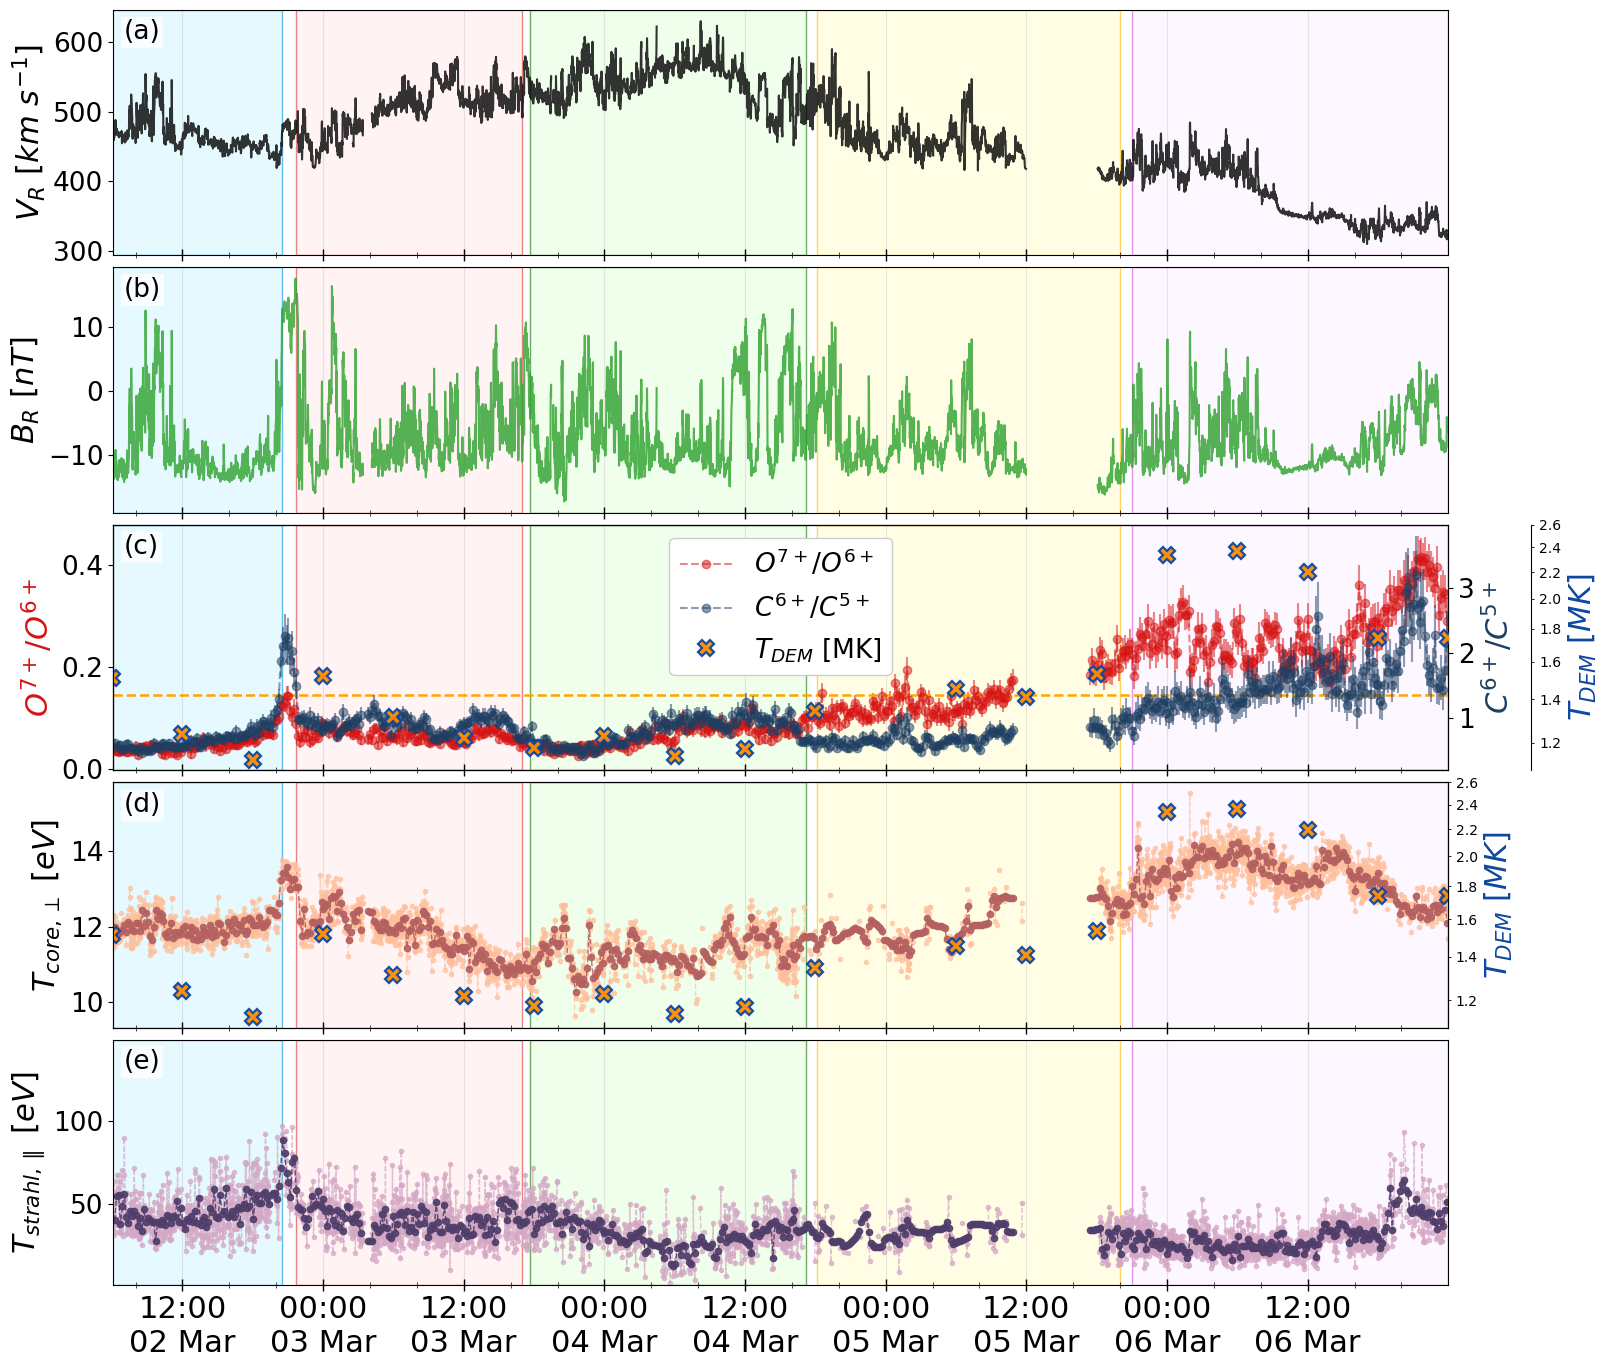

In [14]:
interval_dict = {
    'CH1': (pd.Timestamp('2022-03-02T06:00:00'), pd.Timestamp('2022-03-02T20:30:00'),'#D4F6FF', '#0094DE'),
    'CH2': (pd.Timestamp('2022-03-02T21:40:00'), pd.Timestamp('2022-03-03T17:00:00'),'#FFECEB','#D63636'),
    'CH3': (pd.Timestamp('2022-03-03T17:40:00'), pd.Timestamp('2022-03-04T17:10:00'),'#E6FFDE','#0E7300'),
    'AR1': (pd.Timestamp('2022-03-04T18:10:00'), pd.Timestamp('2022-03-05T20:00:00'),'#FFFED5','#FFBA05'),
    'AR2': (pd.Timestamp('2022-03-05T21:00:00'), pd.Timestamp('2022-03-07T00:00:00'),'#FCF2FF', '#D952D9')
}

# DEM footpoint temperature: 指定一个 CSV 即可; 不指定 (None) 则不画
dem_csv = '/disk/plasma/xw2/PFSS/results/footpoint_temperature_aggregated_20220302T060000_to_20220307T000000.csv'
dem_T = load_DEM_temperature(dem_csv) if dem_csv is not None else None

# 使用新的绘图函数 (无 PAD panel, 5 panels)
swa_fig_dir = '/disk/plasma/xw2/PFSS/results/compare_T_insitu_DEM/'+'T_insitu_DEM_comparison_'+f'{pd.Timestamp(t_start).strftime("%Y%m%d%H%M")}_{pd.Timestamp(t_end).strftime("%Y%m%d%H%M")}'+'.png'
plot_SWA_with_gaps_filled(time_index_filled, magVector_filled, vpVector_filled,
                          Cvb=None, HIS_data=HIS_data_filled,
                          T_core_dict=T_core_filled, T_strahl_dict=T_strahl_filled,
                          save_dir=swa_fig_dir, interval_segments=interval_dict,
                          dem_T=dem_T)